In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kaggle
import logging

log = logging.getLogger(__name__)
csv_save_location = os.path.join("..","output")
charts_save_location = os.path.join("..","output","charts")

In [6]:
def save_csv(df: pd.DataFrame, path)-> None:
    df.to_csv(df,path)

In [7]:
# netflix-shows dataset
kaggle.api.authenticate()
kaggle.api.dataset_download_files(
    'shivamb/netflix-shows',
    path='../data/raw/', unzip=True
)
netflix = pd.read_csv('../data/raw/netflix_titles.csv')
# chess_games dataset
chess = pd.read_csv('../data/raw/chess_games.csv')
# temp dataset
temp = pd.read_csv(
  'https://raw.githubusercontent.com/datasets/global-temp/main/data/annual.csv'
)
temp_monthly = pd.read_csv(
    "https://raw.githubusercontent.com/datasets/global-temp/main/data/monthly.csv")


Dataset URL: https://www.kaggle.com/datasets/shivamb/netflix-shows


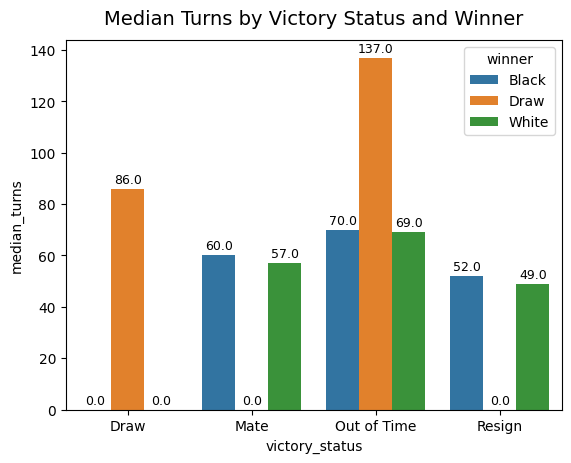

In [8]:
pivot_tabled_df = chess.pivot_table(
values = 'turns', 
index = 'victory_status' , 
columns = 'winner',
aggfunc = 'median', 
fill_value = 0,
).round(1)
long = pivot_tabled_df.reset_index().melt(id_vars= 'victory_status' , var_name= 'winner', value_name= 'median_turns' )
ax = sns.barplot(data=long, x= 'victory_status' , y='median_turns' , hue='winner')
for container in ax.containers:
    labels = [f'{v.get_height():.1f}' for v in container]
    ax.bar_label(container, labels=labels, padding=2, fontsize=9)
plt.title('Median Turns by Victory Status and Winner', fontsize=14, y=1.02)
plt.savefig(os.path.join(charts_save_location,'AQ1.png'), dpi=150, bbox_inches='tight')
plt.show()

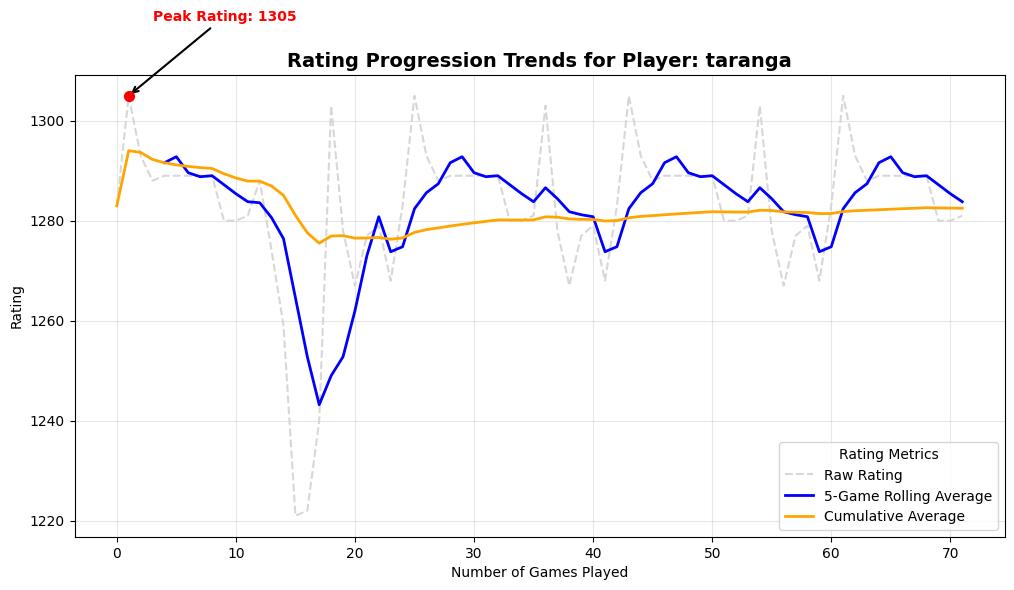

In [9]:
white_games= chess['white_id'].value_counts()
player_name = white_games[white_games >=15].index[0]
player = chess[chess['white_id']==player_name].sort_values('game_id').reset_index(drop=True)
player['rolling_5_rating'] = player['white_rating'].rolling(window=5).mean()
player['cum_avg_rating' ] =player['white_rating' ].expanding().mean()

max_rating = player['white_rating'].max()
max_game_index = player['white_rating'].idxmax()

plt.figure(figsize=(12, 6))

plt.plot(player.index, player['white_rating'], label='Raw Rating', color='lightgray', alpha=0.9, linestyle='--')
plt.plot(player.index, player['rolling_5_rating'], label='5-Game Rolling Average', color='blue', linewidth=2)
plt.plot(player.index, player['cum_avg_rating'], label='Cumulative Average', color='orange', linewidth=2)

# Annotate the highest-rated -game
plt.annotate(
    f'Peak Rating: {max_rating}', 
    xy=(max_game_index, max_rating),         
    xytext=(max_game_index + 2, max_rating + 15), 
    arrowprops=dict(
        facecolor='black',                    
        arrowstyle='->',                      #
        lw=1.5                                
    ),
    fontweight='bold',
    color='red'                               
)

plt.scatter(max_game_index, max_rating, color='red', s=50, zorder=5)
# Add chart elements
plt.title(f'Rating Progression Trends for Player: {player_name}', fontsize=14, fontweight='bold')
plt.xlabel('Number of Games Played')
plt.ylabel('Rating')
plt.legend(title='Rating Metrics')  # Explains which line is which
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(charts_save_location,'AQ2.png'), dpi=150, bbox_inches='tight')
plt.show()

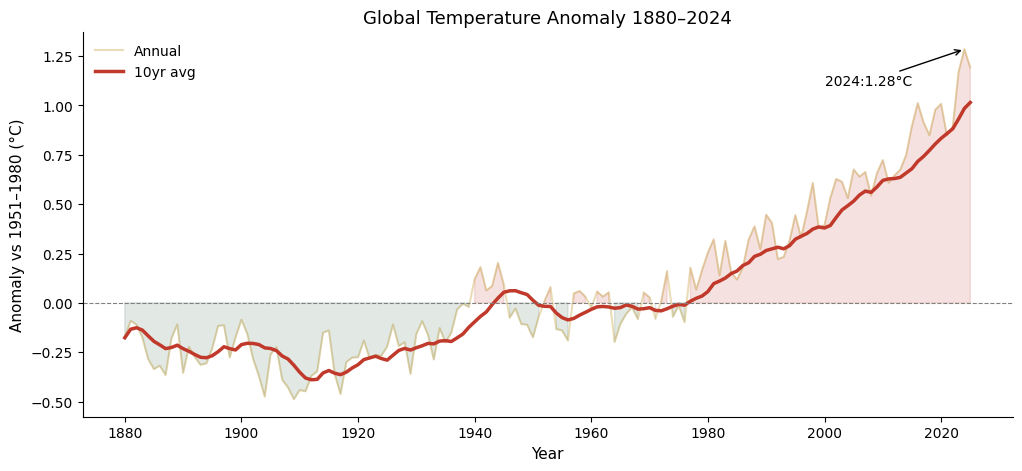

In [10]:
gistemp = temp[temp['Source']=='GISTEMP'].copy()
gistemp['rolling_10'] = gistemp['Mean'].rolling(10, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(12, 5))
# Raw annual · 10-year rolling · zero baseline
ax.plot(gistemp['Year'], gistemp['Mean'], color='#C9A84C', alpha=0.4, label='Annual')
ax.plot(gistemp['Year'], gistemp['rolling_10'], color='#C0392B', linewidth=2.5, label='10yr avg')
ax.axhline(y=0, color='grey', linewidth=0.8, linestyle='--')
# Shade above/below the baseline
ax.fill_between(gistemp['Year'],0,gistemp['Mean'], where=gistemp['Mean']>0, alpha=0.15, color='#C0392B')
ax.fill_between(gistemp['Year'],0,gistemp['Mean'], where=gistemp['Mean']<=0, alpha=0.15, color='#3D6B4F')

ax.set_title('Global Temperature Anomaly 1880–2024', fontsize=13)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Anomaly vs 1951–1980 (°C)', fontsize=11)
ax.legend(frameon=False, loc='upper left')
ax.spines[['top','right']].set_visible(False)

# Annotation
max_mean = gistemp.sort_values(by='Mean', ascending=False)[['Year', 'Mean']].head(1)['Mean'].iloc[0]
year_max_mean = gistemp.sort_values(by='Mean', ascending=False)[['Year', 'Mean']].head(1)['Year'].iloc[0]
ax.annotate(str(year_max_mean)+':'+ str(max_mean.round(2))+'°C',
xy=(year_max_mean, max_mean), xytext=(2000,
1.1),
arrowprops=dict(arrowstyle='->',
color='black'))
plt.savefig(os.path.join(charts_save_location,'AQ3.png'), dpi=150, bbox_inches='tight')

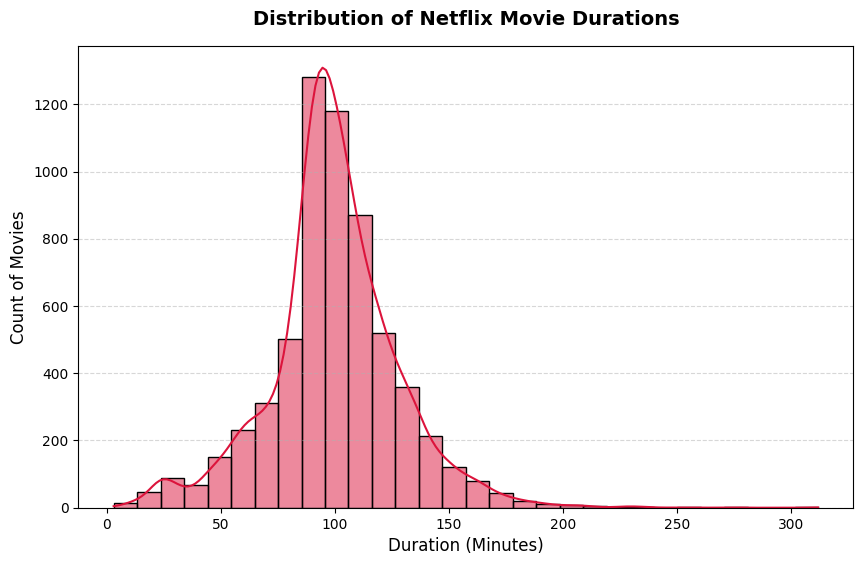

In [11]:
### AQ4-a
movies = netflix[netflix['type']=='Movie']
movies = movies.dropna(subset=['duration'])
movies['duration_min'] = movies['duration'].str.replace(' min','').astype(int)
plt.figure(figsize=(10, 6))

sns.histplot(
    data=movies, 
    x='duration_min', 
    bins=30,            
    kde=True,           
    color='crimson',   
    edgecolor='black'
)

plt.title('Distribution of Netflix Movie Durations', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Duration (Minutes)', fontsize=12)
plt.ylabel('Count of Movies', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.savefig(os.path.join(charts_save_location,'AQ4-a_netflix_movie_duration_histogram.png'), dpi=300, bbox_inches='tight')
plt.show()

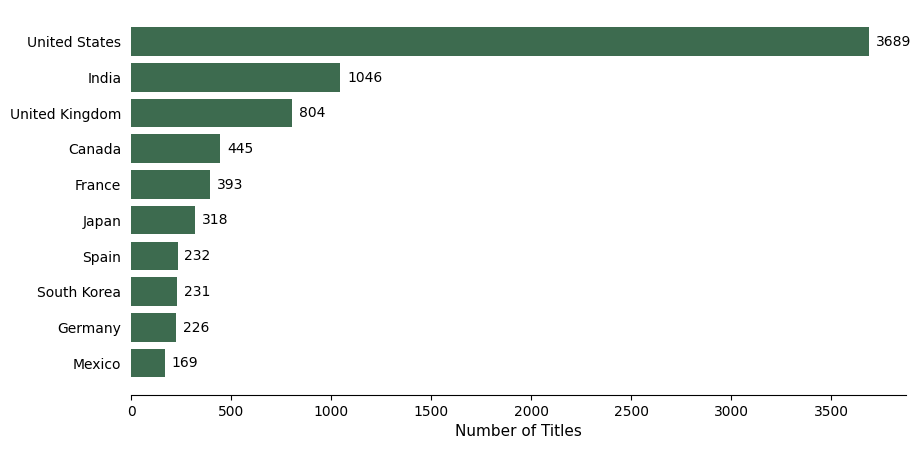

In [12]:
#####
countries = (netflix['country'].dropna()
.str.split(', ', expand=True)
.stack()
.reset_index(drop=True)
.rename('country').to_frame())
top10 = countries['country'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
top10.index[::-1],
top10.values[::-1],
color='#3D6B4F'
)
ax.bar_label(bars, padding=5, fontsize=10)
ax.set_xlabel('Number of Titles', fontsize=11)
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(left=False)
plt.savefig(os.path.join(charts_save_location,'AQ4-b_netflix_top10_countries.png'), dpi=300, bbox_inches='tight')
plt.show()

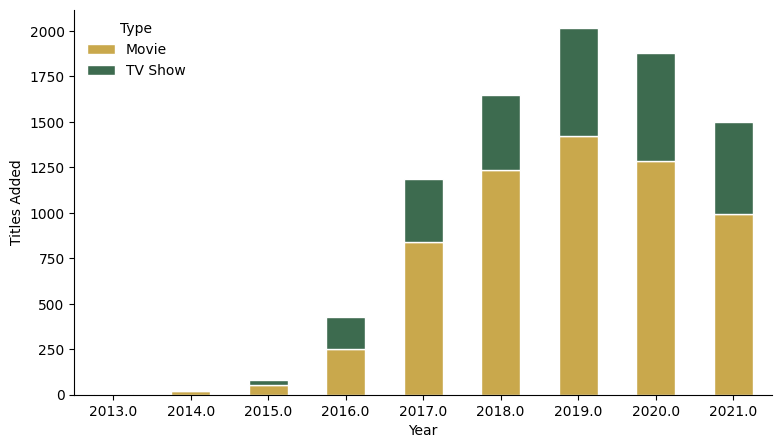

In [13]:
# AQ4-c
netflix['year_added'] = pd.to_datetime(
netflix['date_added'].str.strip(),
errors='coerce').dt.year
added = (netflix[netflix['year_added'].between(2013,2021)]
.groupby(['year_added','type']).size()
.reset_index(name='count'))
wide = added.pivot(
index='year_added', columns='type',
values='count').fillna(0)
fig, ax = plt.subplots(figsize=(9, 5))
wide.plot(kind='bar', stacked=True, ax=ax,
color=['#C9A84C','#3D6B4F'],
edgecolor='white')
ax.set_xlabel('Year'); ax.set_ylabel('Titles Added')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Type', frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.savefig(os.path.join(charts_save_location,'AQ4-c_netflix_stacked_bar.png'), dpi=300, bbox_inches='tight')
plt.show()

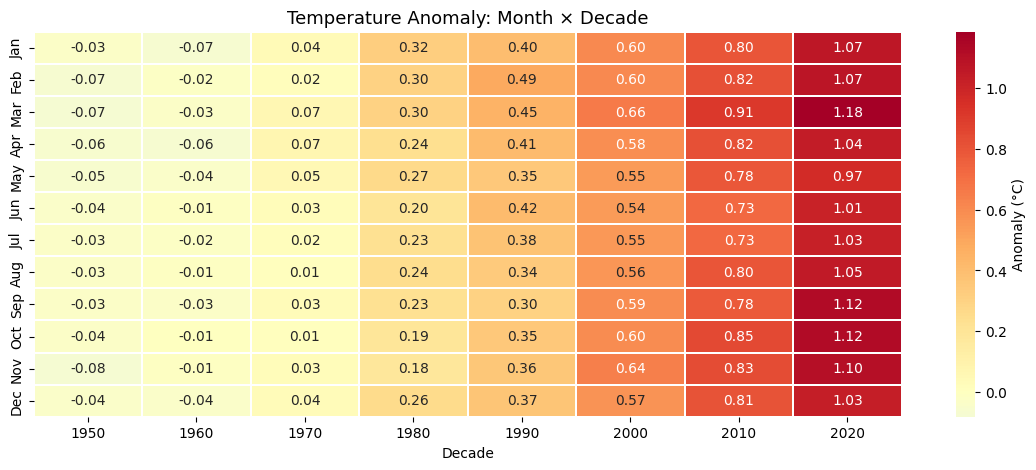

In [14]:
# AQ5
temp_m2 = temp_monthly.copy()
temp_m2['date'] = pd.to_datetime(temp_m2['Year'], format='%Y-%m')
temp_m2['year'] = temp_m2['date'].dt.year
temp_m2['month'] = temp_m2['date'].dt.month
temp_m2['decade'] = (temp_m2['year'] // 10) * 10
gm = temp_m2[temp_m2['Source']=='GISTEMP']
pivot = gm.pivot_table(index='month', columns='decade', values='Mean', aggfunc='mean')
pivot.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot[[c for c in pivot.columns if c>=1950]],
annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
linewidths=0.3, ax=ax, cbar_kws={'label':'Anomaly (°C)'})
ax.set_title('Temperature Anomaly: Month × Decade', fontsize=13)
ax.set_xlabel('Decade'); ax.set_ylabel('')
plt.savefig(os.path.join(charts_save_location,'AQ5_temp_heatmap.png'), bbox_inches='tight')
plt.show()